<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[InceptionNet v3] Epoch   1/100 | LR: 1.38e-03 | train loss 1.8619 acc 0.428 | val loss 1.1637 acc 0.297 *


[InceptionNet v3] Epoch   2/100 | LR: 1.38e-03 | train loss 1.1322 acc 0.595 | val loss 0.9745 acc 0.622 *


[InceptionNet v3] Epoch   3/100 | LR: 1.38e-03 | train loss 1.1239 acc 0.637 | val loss 0.6633 acc 0.754 *


[InceptionNet v3] Epoch   4/100 | LR: 1.38e-03 | train loss 1.0759 acc 0.674 | val loss 2.0342 acc 0.461


...

[InceptionNet v3] Epoch  14/100 | LR: 1.38e-03 | train loss 0.5236 acc 0.829 | val loss 0.5323 acc 0.820


[InceptionNet v3] Epoch  15/100 | LR: 1.38e-03 | train loss 0.4908 acc 0.858 | val loss 0.5479 acc 0.851


[InceptionNet v3] Epoch  16/100 | LR: 1.38e-03 | train loss 0.3923 acc 0.877 | val loss 0.7155 acc 0.798


[InceptionNet v3] Epoch  17/100 | LR: 1.38e-03 | train loss 0.4273 acc 0.873 | val loss 0.5880 acc 0.784


[InceptionNet v3] Epoch  18/100 | LR: 1.38e-03 | train loss 0.3371 acc 0.896 | val loss 0.6297 acc 0.826

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 18.

[InceptionNet v3] Restored best checkpoint (val loss = 0.5152)


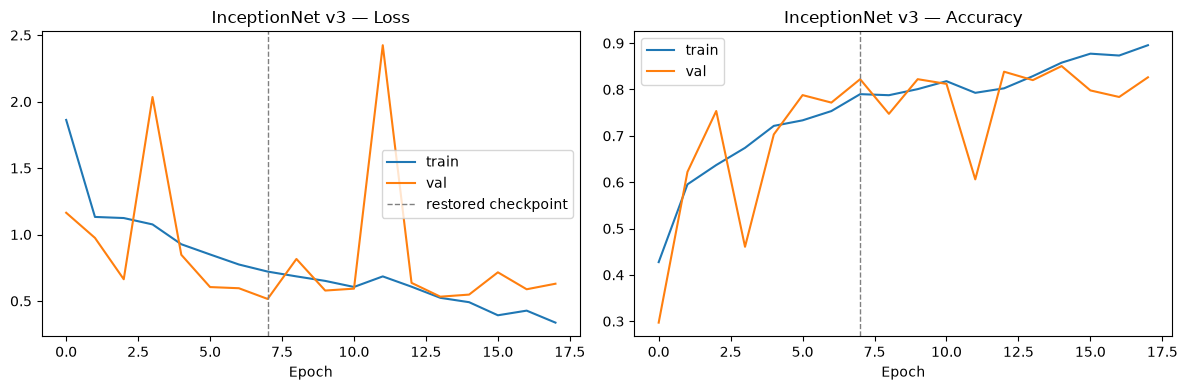

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.825


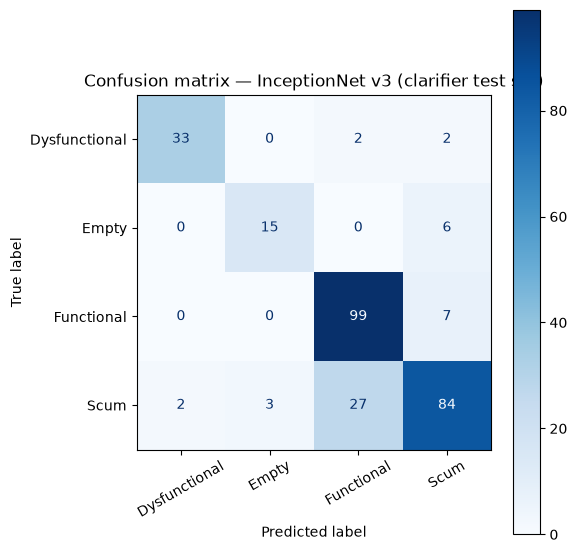

               precision    recall  f1-score   support

Dysfunctional      0.943     0.892     0.917        37
        Empty      0.833     0.714     0.769        21
   Functional      0.773     0.934     0.846       106
         Scum      0.848     0.724     0.781       116

     accuracy                          0.825       280
    macro avg      0.850     0.816     0.828       280
 weighted avg      0.831     0.825     0.823       280



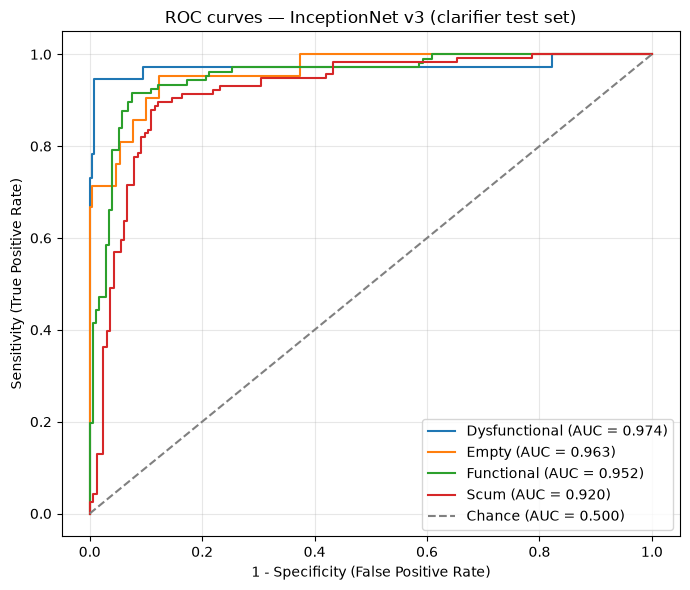

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.974
  Empty          : 0.963
  Functional     : 0.952
  Scum           : 0.920

Mean AUC (over 4/4 classes with test examples): 0.952


(np.float64(0.825),
 {'Dysfunctional': 0.9736403069736403,
  'Empty': 0.9628608200036772,
  'Functional': 0.952450661461722,
  'Scum': 0.9198380992430614})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/clarifier_noaug/results_clarifier_inception_v3_stratified.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
